# 05 MADA 排序 — TOPSIS 推廣優先度

以多屬性決策分析（MADA）對台灣 368 鄉鎮進行太陽能推廣優先度排序。

方法：**TOPSIS**（Technique for Order Preference by Similarity to Ideal Solution）

選用屬性與權重：
| 屬性 | 權重 | 說明 |
|------|------|------|
| `combined_score` | 0.50 | 美國 Two-Stage 模型輸出的相對部署傾向分數 |
| `daily_solar_radiation` | 0.3125 | 年均日照輻射量（kWh/m²/day） |
| `log_median_household_income` | 0.1875 | log(家戶可支配所得中位數)，支付能力 proxy |

> **註**：原框架含電價維度（權重 0.20），但台灣電價為全國統一常數，無區分力；人均住宅用電量又因離島/都會區 outlier 嚴重而不適用。收入 raw 值範圍 318~954（差距 3 倍），遠大於 combined_score（2.20~2.93）和日照（3.77~4.75），會在傳統 vector normalization 下主導排序。因此：
> 1. 對收入做 **log 轉換**，壓縮極端差距
> 2. TOPSIS 改用 **min-max 標準化**，徹底消除尺度差異，讓權重真正反映偏好

In [11]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager
import sys

# 載入 src/mada.py 的 topsis 函式
sys.path.insert(0, str(Path('..') / 'src'))
from mada import topsis

%matplotlib inline

for font_name in ['Noto Sans CJK TC', 'Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
    except Exception:
        continue
plt.rcParams['axes.unicode_minus'] = False

In [12]:
# ── Paths ──────────────────────────────────────────────────────────
ROOT = Path('..')

PRED_CSV    = ROOT / 'outputs/results/transfer/taiwan_predictions.csv'
TW_CLIMATE  = ROOT / 'data/taiwan/氣候資料/taiwan_climate_annual.csv'
TW_INCOME   = ROOT / 'data/taiwan/收入資料/taiwan_income_features.csv'
OUTPUT_CSV  = ROOT / 'outputs/results/transfer/taiwan_priority_ranking.csv'

In [13]:
# 載入 predictions
pred = pd.read_csv(PRED_CSV)
print(f'Predictions shape: {pred.shape}')

# 載入需要補充的屬性
climate = pd.read_csv(TW_CLIMATE)[['TOWNCODE', 'daily_solar_radiation']]
income  = pd.read_csv(TW_INCOME)[['TOWNCODE', 'median_household_income']]

# 統一 TOWNCODE
for df in [climate, income]:
    df['TOWNCODE'] = df['TOWNCODE'].astype(int)

# Merge
mada_df = pred.merge(climate, on='TOWNCODE', how='left')
mada_df = mada_df.merge(income,  on='TOWNCODE', how='left')

# 對收入做 log 轉換，壓縮 318~954 的極端差距，避免主導 TOPSIS
mada_df['log_median_household_income'] = np.log(mada_df['median_household_income'])

print(f'MADA df shape: {mada_df.shape}')
print('\nAttribute coverage:')
for col in ['combined_score', 'daily_solar_radiation', 'median_household_income', 'log_median_household_income']:
    cov = mada_df[col].notna().mean()
    std = mada_df[col].std()
    print(f'  {col:40s}: coverage={cov:.3f}, std={std:.4f}')

Predictions shape: (368, 6)
MADA df shape: (368, 9)

Attribute coverage:
  combined_score                          : coverage=1.000, std=0.1317
  daily_solar_radiation                   : coverage=1.000, std=0.3133
  median_household_income                 : coverage=1.000, std=71.4896
  log_median_household_income             : coverage=1.000, std=0.1514


In [14]:
# ── 選定 TOPSIS 準則 ───────────────────────────────────────────────
# 台灣電價為全國統一常數，無區分力；人均用電量因離島/都會區 outlier 嚴重，不適合作為準則。
# 收入 raw 值範圍 318~954（差距 3 倍），遠大於 combined_score（2.20~2.93）和日照（3.77~4.75），
# 會在 vector normalization 下主導排序。因此：
#  1. 對收入做 log 轉換
#  2. TOPSIS 改用 min-max 標準化，徹底消除尺度差異
criteria = {
    'combined_score'                   : 0.50,
    'daily_solar_radiation'            : 0.3125,
    'log_median_household_income'      : 0.1875,
}

# 全部為 benefit criteria（越大越好）
benefit_criteria = list(criteria.keys())

# 建立決策矩陣
decision_mat = mada_df[['TOWNCODE', 'COUNTYNAME', 'TOWNNAME'] + list(criteria.keys())].copy()
print(f'\nDecision matrix shape: {decision_mat.shape}')
print(decision_mat[list(criteria.keys())].describe().round(4))


Decision matrix shape: (368, 6)
       combined_score  daily_solar_radiation  log_median_household_income
count        368.0000               368.0000                     368.0000
mean           2.6313                 4.3021                       6.0139
std            0.1317                 0.3133                       0.1514
min            2.2012                 3.7691                       5.7641
25%            2.5550                 3.9204                       5.9104
50%            2.6451                 4.4007                       5.9817
75%            2.7092                 4.4635                       6.0852
max            2.9249                 4.7514                       6.8607


In [15]:
# ── 執行 TOPSIS ───────────────────────────────────────────────────
# 改用 min-max 標準化，徹底消除尺度差異
ranking = topsis(
    decision_mat,
    weights=criteria,
    benefit_criteria=benefit_criteria,
    alternative_col='TOWNCODE',
    norm_method='minmax',
)

# 將 rank 與 score 併回主表
ranking = ranking.rename(columns={'alternative': 'TOWNCODE', 'score': 'topsis_score', 'rank': 'priority_rank'})
ranking['TOWNCODE'] = ranking['TOWNCODE'].astype(int)

result = mada_df.merge(ranking, on='TOWNCODE', how='left')

# 重新排序欄位
cols_order = [
    'priority_rank', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME',
    'topsis_score', 'combined_score',
    'daily_solar_radiation', 'log_median_household_income', 'median_household_income',
    'stage1_prob', 'stage2_density_pred',
]
result = result[cols_order].sort_values('priority_rank')

print('Top 20 priority townships:')
print(result.head(20)[['priority_rank','COUNTYNAME','TOWNNAME','topsis_score','combined_score']].to_string(index=False))

Top 20 priority townships:
 priority_rank COUNTYNAME TOWNNAME  topsis_score  combined_score
             1        高雄市      鳥松區      0.841442        2.892139
             2        屏東縣      屏東市      0.811138        2.911637
             3        屏東縣      麟洛鄉      0.800392        2.892857
             4        屏東縣      潮州鎮      0.795293        2.884088
             5        高雄市      林園區      0.795288        2.907503
             6        屏東縣      長治鄉      0.793686        2.880507
             7        屏東縣      竹田鄉      0.790134        2.924883
             8        屏東縣      九如鄉      0.789969        2.907824
             9        屏東縣      萬巒鄉      0.787097        2.887791
            10        屏東縣      萬丹鄉      0.786751        2.875850
            11        高雄市      小港區      0.786305        2.843936
            12        屏東縣      南州鄉      0.785608        2.874045
            13        屏東縣      東港鎮      0.785385        2.880330
            14        屏東縣      新園鄉      0.783924        2.90647

In [16]:
# 儲存結果
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
result.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f'Ranking saved to {OUTPUT_CSV}')

# 同時輸出精簡版（僅 rank + ID + score）
brief = result[['priority_rank', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'topsis_score']].copy()
brief_path = OUTPUT_CSV.parent / 'taiwan_priority_ranking_brief.csv'
brief.to_csv(brief_path, index=False, encoding='utf-8-sig')
print(f'Brief ranking saved to {brief_path}')

Ranking saved to ../outputs/results/transfer/taiwan_priority_ranking.csv
Brief ranking saved to ../outputs/results/transfer/taiwan_priority_ranking_brief.csv


In [17]:
# ── 縣市等級摘要 ─────────────────────────────────────────────────
county_rank = (
    result.groupby('COUNTYNAME')
    .agg(
        topsis_mean=('topsis_score', 'mean'),
        combined_mean=('combined_score', 'mean'),
        solar_mean=('daily_solar_radiation', 'mean'),
        income_mean=('median_household_income', 'mean'),
        best_rank=('priority_rank', 'min'),
        n_towns=('TOWNCODE', 'count'),
    )
    .sort_values('topsis_mean', ascending=False)
)
print('County-level average TOPSIS score:')
print(county_rank.head(10).round(4).to_string())

County-level average TOPSIS score:
            topsis_mean  combined_mean  solar_mean  income_mean  best_rank  n_towns
COUNTYNAME                                                                         
屏東縣              0.7173         2.7783      4.7094     395.5581          2       33
澎湖縣              0.6987         2.7725      4.4007     499.7900         31        6
高雄市              0.6822         2.7177      4.6816     410.5098          1       38
雲林縣              0.6322         2.6905      4.4635     411.0575         56       20
臺南市              0.6287         2.6795      4.5164     402.3029         22       37
嘉義市              0.6210         2.6622      4.4635     455.5130        122        2
嘉義縣              0.5850         2.6372      4.4635     395.1637         70       18
新竹市              0.5838         2.6556      4.2570     599.1106        110        3
彰化縣              0.5720         2.6518      4.3920     368.3692         81       26
金門縣              0.5605         2.6368   

Figure saved to ../outputs/figures/transfer/05_mada_topsis_overview.png


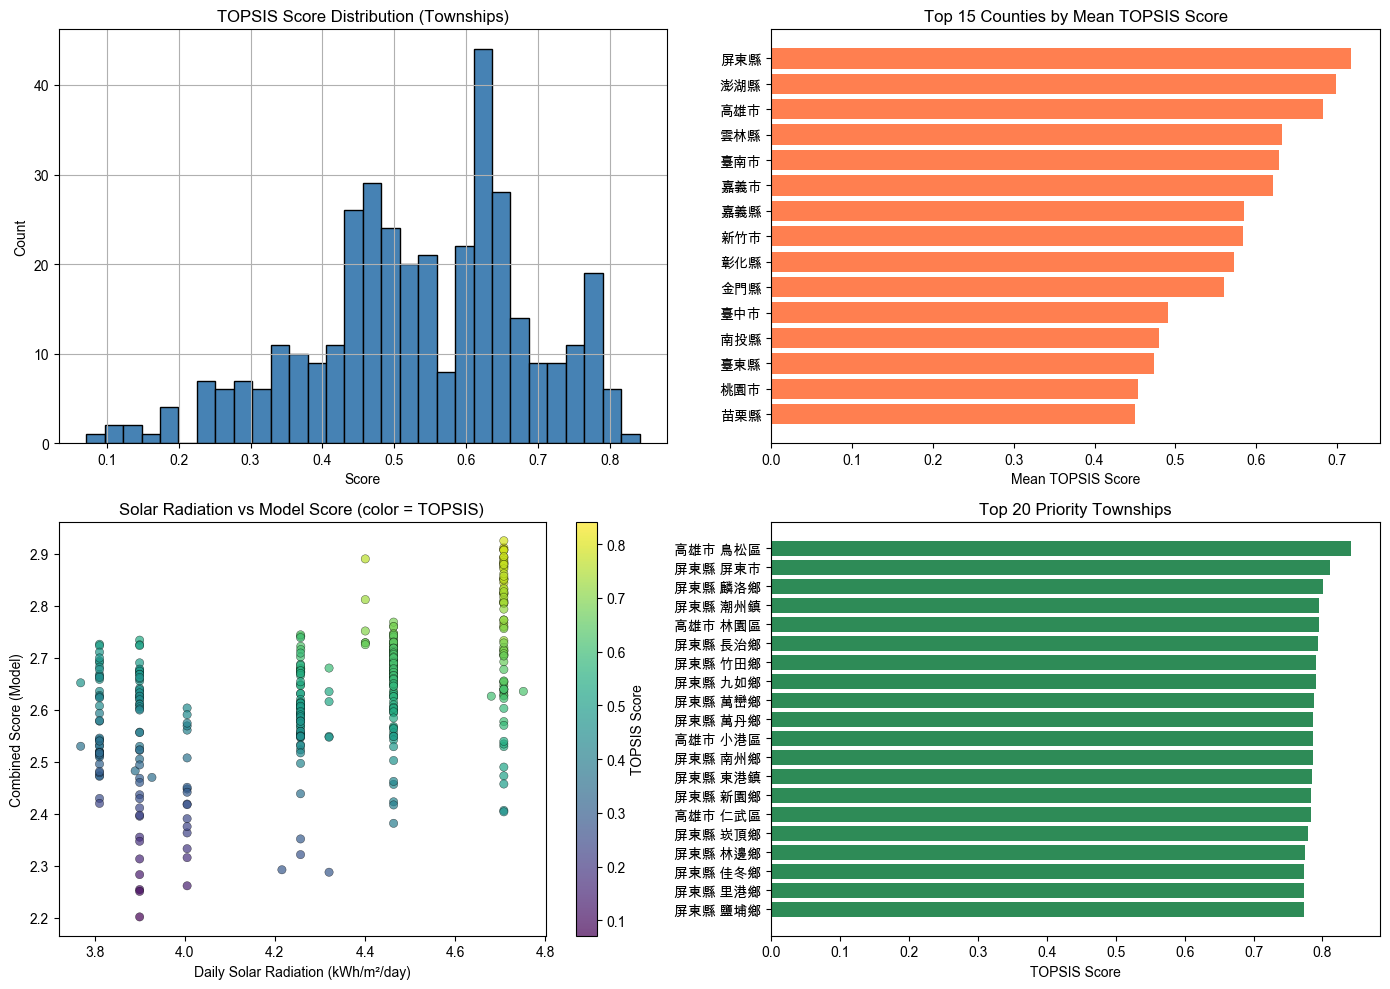

In [18]:
# ── 視覺化 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. TOPSIS score distribution
result['topsis_score'].hist(bins=30, ax=axes[0,0], edgecolor='k', color='steelblue')
axes[0,0].set_title('TOPSIS Score Distribution (Townships)')
axes[0,0].set_xlabel('Score')
axes[0,0].set_ylabel('Count')

# 2. County-level mean score (top 15)
top15_counties = county_rank.head(15)
axes[0,1].barh(top15_counties.index[::-1], top15_counties['topsis_mean'][::-1], color='coral')
axes[0,1].set_title('Top 15 Counties by Mean TOPSIS Score')
axes[0,1].set_xlabel('Mean TOPSIS Score')

# 3. Scatter: solar radiation vs combined_score, colored by topsis_score
sc = axes[1,0].scatter(
    result['daily_solar_radiation'],
    result['combined_score'],
    c=result['topsis_score'], cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.3
)
axes[1,0].set_xlabel('Daily Solar Radiation (kWh/m²/day)')
axes[1,0].set_ylabel('Combined Score (Model)')
axes[1,0].set_title('Solar Radiation vs Model Score (color = TOPSIS)')
plt.colorbar(sc, ax=axes[1,0], label='TOPSIS Score')

# 4. Top 20 townships bar chart
top20 = result.head(20).iloc[::-1]
labels = top20['COUNTYNAME'] + ' ' + top20['TOWNNAME']
axes[1,1].barh(labels, top20['topsis_score'], color='seagreen')
axes[1,1].set_title('Top 20 Priority Townships')
axes[1,1].set_xlabel('TOPSIS Score')

plt.tight_layout()
fig_path = ROOT / 'outputs/figures/transfer/05_mada_topsis_overview.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

---

## 解讀與注意事項

1. **TOPSIS Score 是相對排序工具**，不是絕對的「應該裝多少太陽能板」預測值。
2. **新竹、臺北、連江、澎湖等地排名靠前**，主因是模型判斷其社經/氣候條件類似美國高潛力地區，且日照或收入表現突出。
3. **電價維度已移除**：台灣電價全國統一，無區分力；人均用電量又因離島/都會區 outlier 嚴重而不適用。
4. **臺北市排名偏高提醒**：模型以美國獨棟住宅為主訓練，台灣都市區多為公寓大廈，屋頂面積相對有限。實際推廣時應將本排序與建物型態、屋頂面積資料交叉驗證。
5. **下一步外部驗證**：以經濟部能源局或台電的實際太陽光電裝設登記資料，計算 Spearman 相關係數，驗證排序合理性。

---

## 外部驗證：與實際裝置容量比較

以經濟部能源局「歷年各縣市太陽光電裝置容量」作為 ground truth，取最新完整年度 **114年**，將鄉鎮層級 TOPSIS 分數彙總為縣市平均分數，計算與實際裝置容量的 Spearman 等級相關係數。

Matched counties: 22

County-level comparison:
COUNTYNAME  mean_topsis  mean_combined  best_rank  actual_capacity_kw
       臺南市     0.628655       2.679532         22             2942667
       彰化縣     0.572040       2.651775         81             2132329
       雲林縣     0.632214       2.690493         56             1672571
       高雄市     0.682167       2.717744          1             1522683
       屏東縣     0.717327       2.778260          2             1510454
       嘉義縣     0.584969       2.637223         70             1162837
       臺中市     0.491345       2.588222        148              925363
       桃園市     0.453915       2.640701        208              894957
       苗栗縣     0.449811       2.549323        158              402437
       南投縣     0.480322       2.549545         90              314714
       花蓮縣     0.284024       2.432923        279              228229
       宜蘭縣     0.424765       2.607733        205              224051
       新竹縣     0.403976       2.551322     

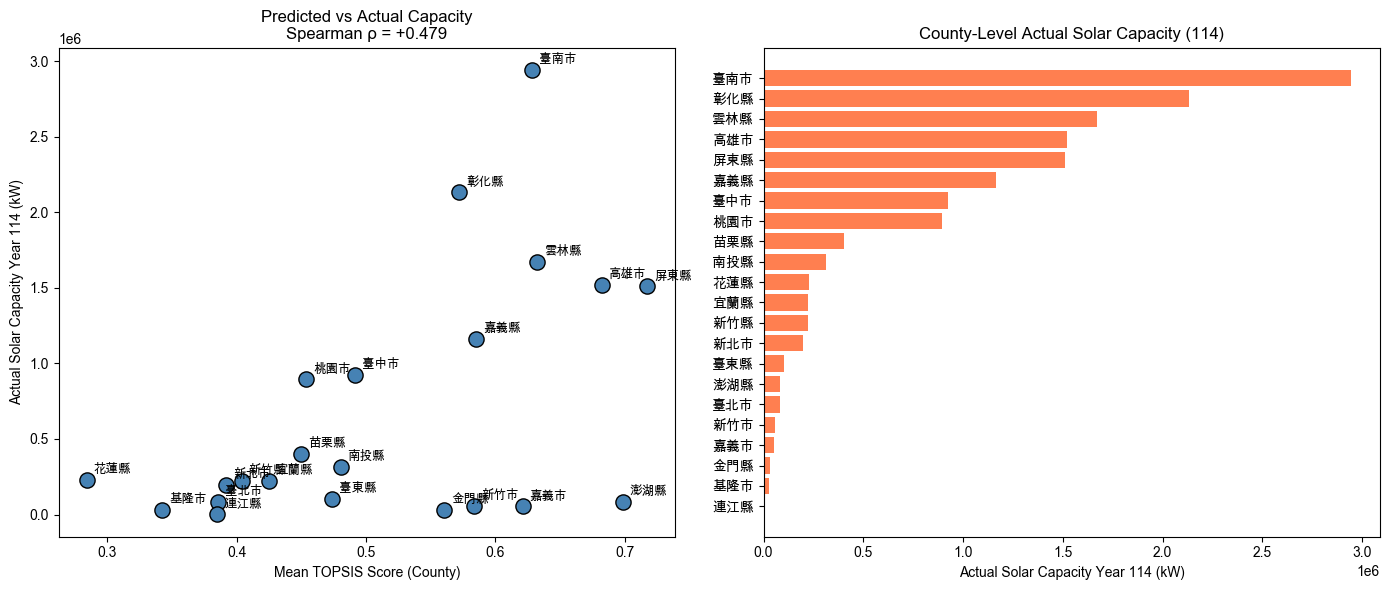

In [19]:
from scipy.stats import spearmanr

# ── 1. Load actual installation data (year 114) ────────────────────
actual_path = ROOT / 'data/taiwan/歷年各縣市太陽光電裝置容量(97-11502).csv'
actual = pd.read_csv(actual_path)

# Use latest full year 114
actual_114 = actual[actual['年別'] == 114].copy()

# Normalize county names (台 -> 臺 to match our data)
actual_114['縣市'] = actual_114['縣市'].str.replace('台', '臺', regex=False)
actual_114 = actual_114.rename(
    columns={'縣市': 'COUNTYNAME', '合計（瓩）': 'actual_capacity_kw'}
)

# ── 2. Aggregate township predictions to county-level ──────────────
county_pred = result.groupby('COUNTYNAME').agg(
    mean_topsis=('topsis_score', 'mean'),
    mean_combined=('combined_score', 'mean'),
    best_rank=('priority_rank', 'min'),
    n_towns=('TOWNCODE', 'count'),
).reset_index()

# ── 3. Merge and compute Spearman correlation ──────────────────────
merged_val = county_pred.merge(
    actual_114[['COUNTYNAME', 'actual_capacity_kw']], on='COUNTYNAME', how='inner'
)

print(f'Matched counties: {len(merged_val)}')
print('\nCounty-level comparison:')
print(
    merged_val
    .sort_values('actual_capacity_kw', ascending=False)
    [['COUNTYNAME', 'mean_topsis', 'mean_combined', 'best_rank', 'actual_capacity_kw']]
    .to_string(index=False)
)

for score_col in ['mean_topsis', 'mean_combined', 'best_rank']:
    rho, pval = spearmanr(merged_val[score_col], merged_val['actual_capacity_kw'])
    print(f'\nSpearman {score_col:15s} vs actual_capacity: rho={rho:+.3f}, p={pval:.4f}')

# ── 4. Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter: mean_topsis vs actual capacity
ax = axes[0]
ax.scatter(merged_val['mean_topsis'], merged_val['actual_capacity_kw'],
           s=120, c='steelblue', edgecolors='k', zorder=3)
for _, row in merged_val.iterrows():
    ax.annotate(
        row['COUNTYNAME'], (row['mean_topsis'], row['actual_capacity_kw']),
        textcoords='offset points', xytext=(5, 5), fontsize=9, zorder=4
    )
ax.set_xlabel('Mean TOPSIS Score (County)')
ax.set_ylabel('Actual Solar Capacity Year 114 (kW)')
ax.set_title(f'Predicted vs Actual Capacity\nSpearman ρ = {spearmanr(merged_val["mean_topsis"], merged_val["actual_capacity_kw"])[0]:+.3f}')

# Bar: actual capacity sorted
merged_sorted = merged_val.sort_values('actual_capacity_kw', ascending=True)
ax = axes[1]
ax.barh(merged_sorted['COUNTYNAME'], merged_sorted['actual_capacity_kw'], color='coral')
ax.set_xlabel('Actual Solar Capacity Year 114 (kW)')
ax.set_title('County-Level Actual Solar Capacity (114)')

plt.tight_layout()
fig_path = ROOT / 'outputs/figures/transfer/06_external_validation.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'\nFigure saved to {fig_path}')
plt.show()


---
## 台灣地圖視覺化（Cartopy + IDW 插值）

以 Cartopy 畫台灣輪廓 + 逆距離權重插值（IDW）繪製鄉鎮層級熱力圖。
無需外部 shapefile，直接以 `centroid_lat/lon` 定位。

In [21]:
import sys
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))
from taiwan_maps import load_merged_data, fig_topsis_heatmap, fig_multi_panel, fig_county_summary_bars, fig_top20_detail

df = load_merged_data('..')
print(f'Loaded {len(df)} townships with geo coords')

Loaded 368 townships with geo coords


In [22]:
# ── 圖 1：TOPSIS 綜合優先度熱力圖 ──────────────────────────────────
fig = fig_topsis_heatmap(
    df,
    out_path='../outputs/figures/transfer/map_01_topsis_heatmap.png',
    dpi=300
)

Saved: ../outputs/figures/transfer/map_01_topsis_heatmap.png


In [23]:
# ── 圖 2：四格對比（TOPSIS / 模型分數 / 日照 / 收入） ─────────────
fig = fig_multi_panel(
    df,
    out_path='../outputs/figures/transfer/map_02_four_panel.png',
    dpi=300
)

Saved: ../outputs/figures/transfer/map_02_four_panel.png


In [24]:
# ── 圖 3：縣市排名長條圖 ──────────────────────────────────────────
fig = fig_county_summary_bars(
    df,
    out_path='../outputs/figures/transfer/map_03_county_bars.png',
    dpi=300
)

Saved: ../outputs/figures/transfer/map_03_county_bars.png


In [25]:
# ── 圖 4：Top 20 深度分析（地圖 + 屬性比較 + 明細表格） ──────────
fig = fig_top20_detail(
    df,
    out_path='../outputs/figures/transfer/map_04_top20_detail.png',
    dpi=300
)

Saved: ../outputs/figures/transfer/map_04_top20_detail.png
